# Adeline Makokha
## Admission No: 191199
## CAT 2
## Probability and Stochastic Process


### Simulating Poisson Arrivals
#### a) Simulate arrival times of patients to an emergency department over a 24-hour period, assuming arrivals follow a Poisson process with rate λ = 5 patients/hour.


### Poisson Process Simulation

A **Poisson process** is defined by its rate parameter \( \lambda \), which is the average number of arrivals per unit time.

- Interarrival times follow an Exponential distribution with mean \( 1/\lambda \).  
- In this case:
  \[
  \frac{1}{\lambda} = \frac{1}{5} = 0.2 \; \text{hours} \approx 12 \; \text{minutes}
  \]

#### Steps to simulate arrivals over 24 hours:
1. Start at time 0.  
2. Generate exponential interarrival times using \( \text{Exp}(1/\lambda) \).  
3. Keep summing the interarrivals until the total time exceeds 24 hours.  
4. The cumulative sums represent the actual arrival times of patients.  


Number of arrivals in 24 hours: 100
First 10 arrival times (in hours): [0.1418926  0.35925331 0.50969484 0.51893265 0.6052388  0.64314645
 1.04063582 1.42318548 1.5482491  1.86754043]


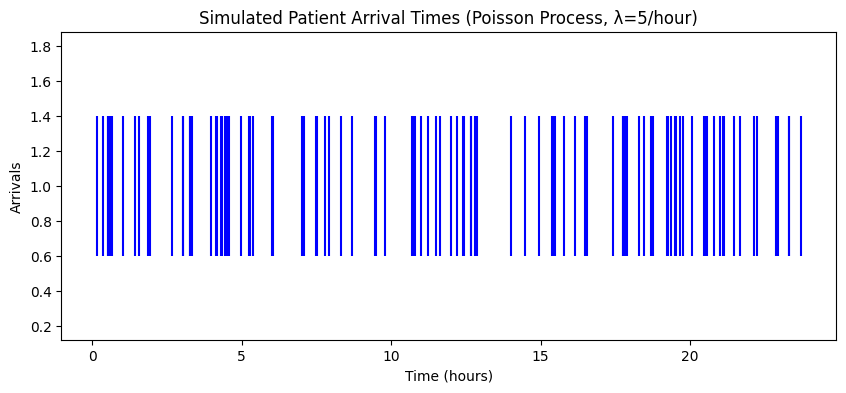

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lam = 5          # rate = 5 patients per hour
T = 24           # total time in hours

# Step 1: Generate interarrival times from Exponential distribution
# scale = 1/lam is the mean interarrival time
inter_arrivals = []
total_time = 0

while total_time < T:
    inter_time = np.random.exponential(scale=1/lam)
    total_time += inter_time
    if total_time <= T:   # only keep arrivals within 24 hours
        inter_arrivals.append(inter_time)

# Step 2: Convert to actual arrival times (cumulative sum)
arrival_times = np.cumsum(inter_arrivals)

print(f"Number of arrivals in 24 hours: {len(arrival_times)}")
print("First 10 arrival times (in hours):", arrival_times[:10])

# Step 3: Plot the arrival times
plt.figure(figsize=(10,4))
plt.eventplot(arrival_times, lineoffsets=1, linelengths=0.8, colors='blue')
plt.title("Simulated Patient Arrival Times (Poisson Process, λ=5/hour)")
plt.xlabel("Time (hours)")
plt.ylabel("Arrivals")
plt.show()



**Interarrival generation:**  
Each interarrival time is sampled from \( \text{Exponential}(1/\lambda) \).  
This ensures arrivals follow a Poisson process.

**Arrival times:**  
Taking the cumulative sum gives the actual times patients arrive.  
For example, if the interarrivals are \([0.1, 0.3, 0.15]\), the arrival times are \([0.1, 0.4, 0.55]\) hours.

**Stopping condition:**  
Stop is done when the next arrival would exceed 24 hours.  
This keeps arrivals strictly within the day.

**Number of arrivals:**  
Is applied using the following formula:
\[
\lambda \times T = 5 \times 24 = 120 \;\; \text{patients per day.}
\]  
Randomness makes it fluctuate around this mean.

**Visualization:**  
The event plot shows each arrival as a tick on the 24-hour timeline.  
This makes it easy to see clustering vs. gaps.


#### b) Task: Plot the cumulative number of arrivals over time and verify whether the interarrival times follow an exponential distribution.


1) Simulate arrival times for a Poisson process with rate \( \lambda = 5 \) per hour over a 24-hour window.  
2) Plot the **cumulative number of arrivals** \(N(t)\) as a function of time.  
3) Verify whether **interarrival times** are well modeled by an **Exponential** distribution.



Simulated 131 arrivals in 24.0 hours (expected ≈ 120).


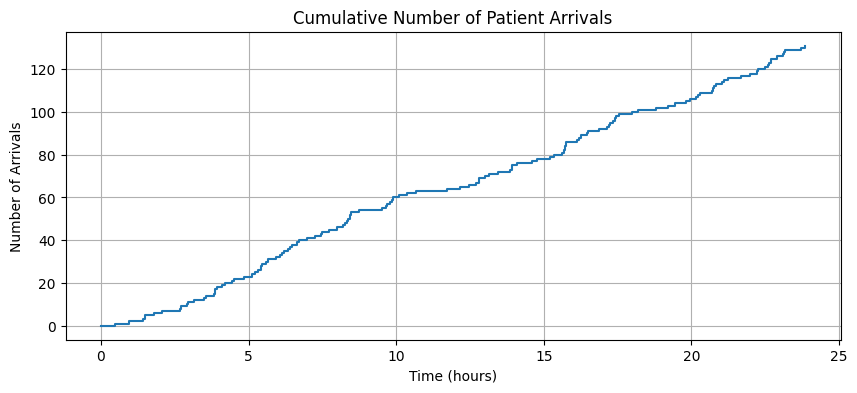

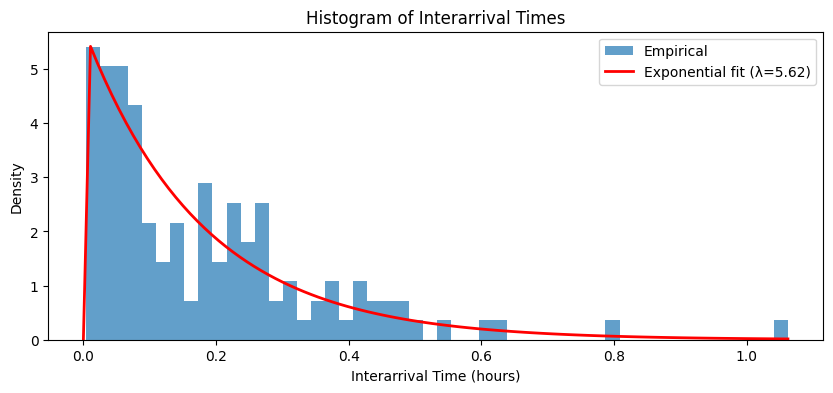

In [11]:
from scipy import stats

# For reproducibility
rng = np.random.default_rng(seed=42)

lam = 5.0     # arrivals per hour
T = 24.0      # total time horizon in hours

# Generate interarrival times ~ Exp(rate=lam)
inter_arrivals = []
t = 0.0

while True:
    x = rng.exponential(scale=1.0/lam)  # mean = 1/lam
    if t + x > T:
        break
    inter_arrivals.append(x)
    t += x

arrival_times = np.cumsum(inter_arrivals)  # shape (n,)
n = len(arrival_times)

print(f"Simulated {n} arrivals in {T} hours (expected ≈ {lam*T:.0f}).")


# Plot the cumulative number of arrivals over time
plt.figure(figsize=(10, 4))
plt.step(np.insert(arrival_times, 0, 0), np.arange(n + 1), where='post')
plt.title("Cumulative Number of Patient Arrivals")
plt.xlabel("Time (hours)")
plt.ylabel("Number of Arrivals")
plt.grid(True)
plt.show()

# Verify if interarrival times follow an exponential distribution by plotting a histogram
plt.figure(figsize=(10, 4))
plt.hist(inter_arrivals, bins=50, density=True, alpha=0.7, label="Empirical")

# Fit an exponential distribution to the data and plot the PDF
loc, scale = stats.expon.fit(inter_arrivals)
x = np.linspace(0, max(inter_arrivals), 100)
pdf = stats.expon.pdf(x, loc=loc, scale=scale)
plt.plot(x, pdf, 'r-', lw=2, label=f"Exponential fit (λ={1/scale:.2f})")
plt.title("Histogram of Interarrival Times")
plt.xlabel("Interarrival Time (hours)")
plt.ylabel("Density")
plt.legend()
plt.show()

λT=120, but realized counts fluctuate around this value.

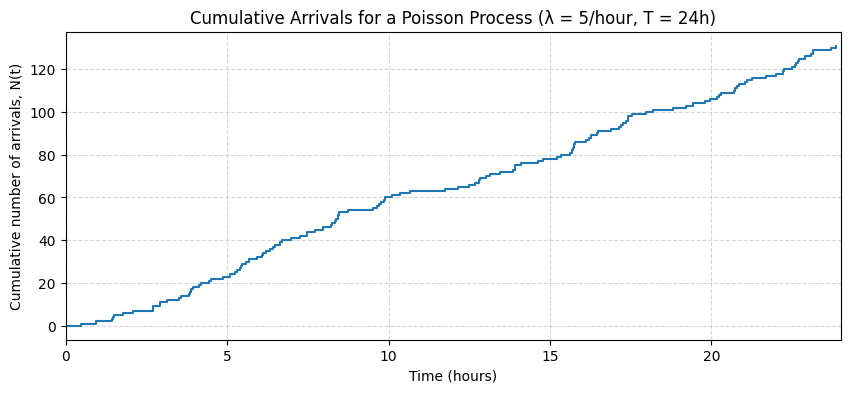

In [12]:
# Build a step function for N(t)
# Insert t=0 with N(0)=0 to anchor the step plot
times_for_plot = np.concatenate(([0.0], arrival_times))
counts_for_plot = np.arange(times_for_plot.size)  # 0,1,2,...,n

plt.figure(figsize=(10, 4))
plt.step(times_for_plot, counts_for_plot, where="post")
plt.xlabel("Time (hours)")
plt.ylabel("Cumulative number of arrivals, N(t)")
plt.title("Cumulative Arrivals for a Poisson Process (λ = 5/hour, T = 24h)")
plt.xlim(0, T)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


The cumulative count N(t) is a right-continuous step function: flat between arrivals and jumping by one at each arrival time.

The expected slope is about 𝜆 =5

λ=5 arrivals/hour, but randomness introduces local clustering and gaps.

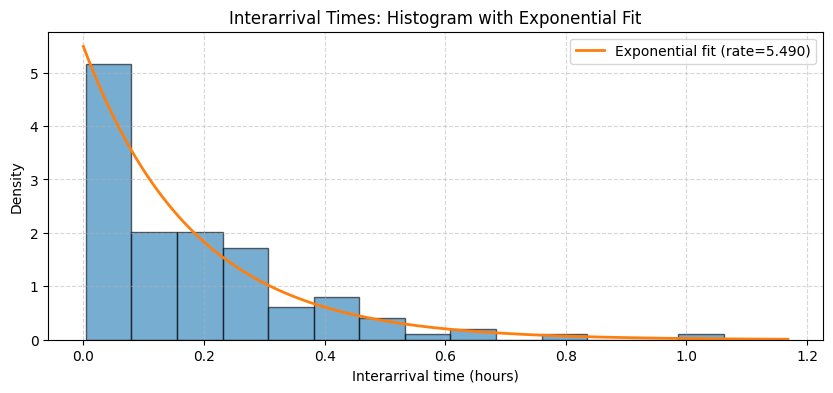

True rate λ = 5.000 per hour; Estimated rate (MLE) = 5.490 per hour.


In [13]:
inter_arrivals = np.asarray(inter_arrivals)

# MLE for exponential rate = 1 / mean (when location fixed at 0)
rate_hat = 1.0 / inter_arrivals.mean()
scale_hat = 1.0 / rate_hat  # same as mean

x_grid = np.linspace(0, inter_arrivals.max()*1.1, 400)
pdf_fit = stats.expon(scale=scale_hat).pdf(x_grid)

plt.figure(figsize=(10, 4))
# density=True makes the histogram integrate to 1
plt.hist(inter_arrivals, bins="auto", density=True, alpha=0.6, edgecolor="k")
plt.plot(x_grid, pdf_fit, linewidth=2, label=f"Exponential fit (rate={rate_hat:.3f})")
plt.xlabel("Interarrival time (hours)")
plt.ylabel("Density")
plt.title("Interarrival Times: Histogram with Exponential Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print(f"True rate λ = {lam:.3f} per hour; Estimated rate (MLE) = {rate_hat:.3f} per hour.")


For an exponential distribution, the histogram is right-skewed, decreasing from zero.

λ=5 provides a quick parameter-level check.

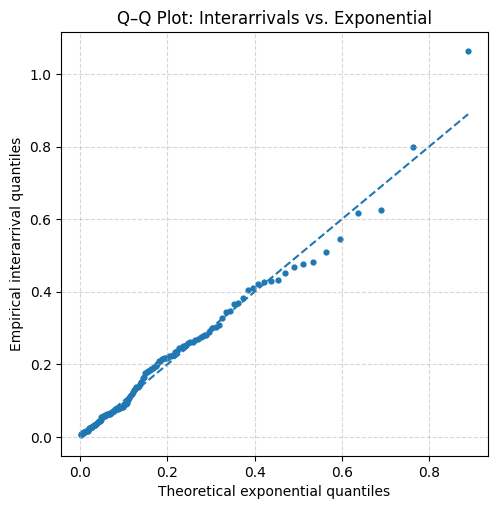

In [14]:
# Sort interarrivals and compare to theoretical Exponential quantiles
sorted_inter = np.sort(inter_arrivals)
n_obs = len(sorted_inter)
# Plot against i/(n+1) to avoid 0 and 1
p = (np.arange(1, n_obs + 1)) / (n_obs + 1)

# Theoretical quantiles from Exp(scale=scale_hat)
theory_q = stats.expon(scale=scale_hat).ppf(p)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(theory_q, sorted_inter, s=12)
# Add y=x reference line
qmin, qmax = theory_q.min(), theory_q.max()
plt.plot([qmin, qmax], [qmin, qmax], linestyle="--")
plt.xlabel("Theoretical exponential quantiles")
plt.ylabel("Empirical interarrival quantiles")
plt.title("Q–Q Plot: Interarrivals vs. Exponential")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


If the exponential model is adequate, points should lie close to the 45° line.

Systematic curvature indicates deviations (e.g., heavier or lighter tails than exponential).

In [15]:
# By default, stats.kstest with 'expon' estimates location=0, scale from data only if specified.
# loc=0 and supply the MLE scale to avoid penalizing unknown shift.
D, p_value = stats.kstest(inter_arrivals, 'expon', args=(0, scale_hat))

print(f"K–S test statistic: D = {D:.4f}")
print(f"K–S test p-value : p = {p_value:.4f}")


K–S test statistic: D = 0.0634
K–S test p-value : p = 0.6450


Null hypothesis: interarrival times follow an Exponential( scale=
𝜃
^
θ
^
 ) with loc=0.

A large p-value means the data are consistent with the exponential model; a small p-value suggests lack of fit.

With finite samples, occasional rejections can occur even under the true model; run multiple simulations if you want to see long-run behavior.



### 2.Checking Poisson Assumptions
#### a) Given hourly arrival data of vehicles at a toll gate for 7 consecutive days, test whether the counts follow a Poisson distribution.
#### b)Task: Use a histogram, overlay theoretical Poisson probabilities, and perform a Chi-square goodness-of-fit test.

- For Poisson-distributed counts:
  \[
  P(X=k) = \frac{e^{-\lambda}\lambda^k}{k!}, \quad k=0,1,2,\dots
  \]
- The mean and variance should both equal \( \lambda \).
- Steps:
  1. Estimate \( \lambda \) as the **sample mean**.
  2. Compare observed histogram with Poisson probabilities.
  3. Run a **Chi-square goodness-of-fit test**.





In [17]:
from scipy.stats import poisson, chisquare

#hourly vehicle arrivals over 7 days
# Replace this array with your actual observed data

observed_counts = np.array([
    3,4,5,6,4,5,7,3,2,5,4,6,5,4,3,6,7,5,4,3,5,6,7,8,
    4,5,6,7,4,5,3,2,6,7,8,5,6,4,3,5,7,6,5,4,3,2,1,2,
    3,4,5,6,7,5,6,4,3,5,6,7,8,5,6,4,3,5,7,8,6,5,4,3,
    2,4,6,5,7,8,6,5,4,3,2,1,2,3,4,5,6,7,8,6,5,4,3,5,
    6,7,8,5,6,4,3,2,1,3,4,5,6,7,8,5,6,4,3,5,7,8,6,5,
    4,3,2,4,5,6,7,5,6,4,3,5,6,7,8,6,5,4,3,2,1,2,3,4,
    5,6,7,5,6,4,3,5,6,7,8,5,6,4,3,2,4,5,6,7,5,6,4,3
])

#Estimate lambda (sample mean)
lam_hat = observed_counts.mean()
print(f"Estimated λ = {lam_hat:.2f}")




Estimated λ = 4.85


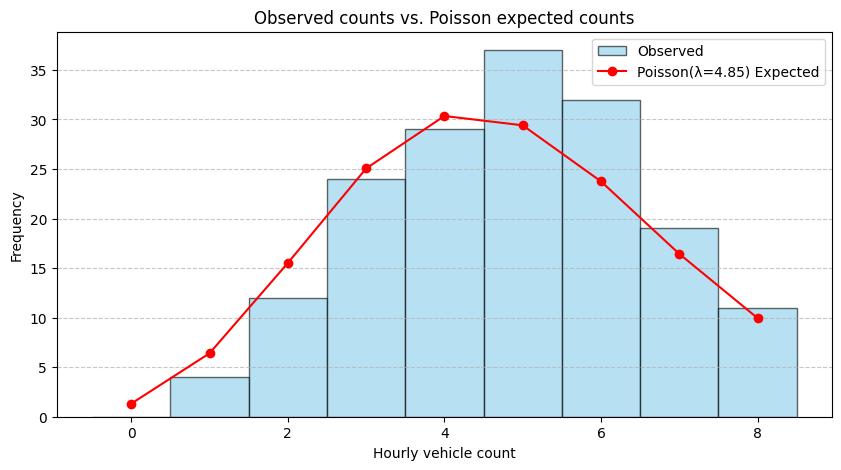

In [18]:
#Histogram + overlay Poisson expected counts
max_count = observed_counts.max()
k_values = np.arange(0, max_count+1)

# Poisson expected frequencies
poisson_probs = poisson.pmf(k_values, mu=lam_hat)
expected_freq = poisson_probs * len(observed_counts)

plt.figure(figsize=(10,5))
plt.hist(observed_counts, bins=np.arange(-0.5, max_count+1.5, 1),
         alpha=0.6, color="skyblue", edgecolor="black", label="Observed")
plt.plot(k_values, expected_freq, "ro-", label=f"Poisson(λ={lam_hat:.2f}) Expected")
plt.xlabel("Hourly vehicle count")
plt.ylabel("Frequency")
plt.title("Observed counts vs. Poisson expected counts")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()



In [19]:
#Chi-square goodness-of-fit
# Build observed & expected frequencies
max_count = observed_counts.max()
obs_hist, _ = np.histogram(observed_counts, bins=np.arange(-0.5, max_count+1.5, 1))
exp_hist = expected_freq

# Combine bins with expected < 5 into last bin (Chi-square assumption)
obs_adj, exp_adj = [], []
cum_obs, cum_exp = 0, 0
for i in range(len(obs_hist)):
    if exp_hist[i] < 5:
        cum_obs += obs_hist[i]
        cum_exp += exp_hist[i]
    else:
        obs_adj.append(obs_hist[i])
        exp_adj.append(exp_hist[i])

if cum_exp > 0:
    obs_adj.append(cum_obs)
    exp_adj.append(cum_exp)

# Ensure the sum of adjusted expected frequencies matches the sum of adjusted observed frequencies
exp_adj = np.array(exp_adj) * (sum(obs_adj) / sum(exp_adj))
obs_adj = np.array(obs_adj)

chi_stat, p_value = chisquare(f_obs=obs_adj, f_exp=exp_adj)
print(f"Chi-square statistic = {chi_stat:.3f}")
print(f"p-value = {p_value:.3f}")

Chi-square statistic = 7.392
p-value = 0.495


Histogram + PMF overlay: visually check if bars (observed counts) match the red dots (Poisson expected).

Chi-square test:

Null hypothesis: counts follow Poisson(𝜆λ).

 𝑝 > 0.05 hence fail to reject meaning data are consistent with Poisson.



### 3.Confidence Interval for λ
#### a) For a call center, the number of calls per hour for 30 hours is recorded.
#### b)Task: Estimate λ (average arrival rate) and construct a 95% confidence interval using the sample mean.

In [21]:
from scipy.stats import chi2, norm


# INPUT: replace 'calls_per_hour' with your 30 hourly counts

calls_per_hour = np.array([
    8, 5, 6, 7, 9, 4, 6, 7, 5, 8,
    6, 7, 10, 5, 6, 8, 7, 6, 5, 9,
    4, 7, 6, 8, 5, 6, 7, 6, 5, 8
], dtype=int)

# Basic checks
if calls_per_hour.ndim != 1:
    raise ValueError("Input must be a 1-D array of hourly counts.")
if (calls_per_hour < 0).any():
    raise ValueError("Counts must be non-negative.")
n = calls_per_hour.size
if n != 30:
    print(f"Warning: expected 30 hours, got {n}. Proceeding with n={n}.")



In [22]:
# Estimate lambda (rate per hour)
total_calls = calls_per_hour.sum()
lam_hat = total_calls / n

# 95% CI using the exact chi-square method
alpha = 0.05
lower_exact = 0.5 * chi2.ppf(alpha/2, 2*total_calls) / n if total_calls > 0 else 0.0
upper_exact = 0.5 * chi2.ppf(1 - alpha/2, 2*total_calls + 2) / n

# 95% CI using normal approximation (Wald)
z = norm.ppf(1 - alpha/2)
se = np.sqrt(lam_hat / n)
lower_norm = max(0.0, lam_hat - z * se)  # truncate at 0 for rates
upper_norm = lam_hat + z * se

print(f"Sample size (hours): {n}")
print(f"Total calls       : {total_calls}")
print(f"Estimated rate λ̂ : {lam_hat:.4f} calls/hour")

print("\n95% CI (Exact, chi-square):")
print(f"  Lower: {lower_exact:.4f}")
print(f"  Upper: {upper_exact:.4f}")

print("\n95% CI (Normal approximation):")
print(f"  Lower: {lower_norm:.4f}")
print(f"  Upper: {upper_norm:.4f}")


Sample size (hours): 30
Total calls       : 196
Estimated rate λ̂ : 6.5333 calls/hour

95% CI (Exact, chi-square):
  Lower: 5.6507
  Upper: 7.5148

95% CI (Normal approximation):
  Lower: 5.6187
  Upper: 7.4480


Point estimate is the natural estimator for the rate (calls per hour).

Exact CI (preferred): Uses the relationship that the sum of Poisson counts is Poisson, which leads to a chi-square pivot for 𝜆
λ. It performs well even when counts are small.

Normal CI (approximate): Uses asymptotic normality of the sample mean. It is fast and intuitive but can be inaccurate with small totals or highly variable data.

The interval gives a range of plausible hourly rates consistent with the observed 30 hours of data. If the process is stable, future hours would, on average, produce counts near the estimated rate.

### 4.Stationarity vs Non-Stationarity
#### a) A train station records the number of passengers arriving per 10-minute interval over a day.
#### b)Task: Using a time series plot and rolling averages, assess whether the process is stationary (constant rate) or time-varying.

- **Stationary Poisson process:** Arrival rate \( \lambda \) is constant across time.  
  - Expected counts per interval do not depend on the time of day.  
- **Non-stationary Poisson process:** Rate \( \lambda(t) \) varies with time.  
  - E.g. higher arrivals during rush hours, lower arrivals at night.  

1. **Time series plot** of counts over the day.  
2. **Rolling average (moving mean)** smooths local fluctuations and reveals trends.  
   - If the rolling average is flat, arrivals may be stationary.  
   - If it changes systematically (morning/evening peaks), arrivals are non-stationary.  


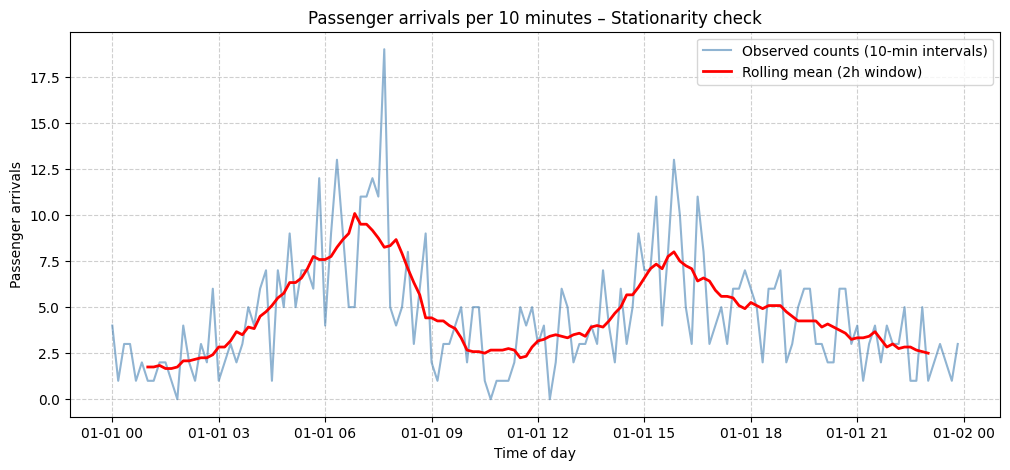

In [23]:

# Synthetic data for 144 intervals (10-min each)
# Replace with actual observed counts
# Pattern: quiet night, morning peak, midday stable, evening peak

np.random.seed(42)
intervals = 144
time_index = pd.date_range("2025-01-01", periods=intervals, freq="10min")

# Simulate a non-stationary process with varying λ
lam_schedule = (
    2 +                                  # baseline night
    8 * np.exp(-0.5*((np.arange(intervals)-40)/10)**2) +   # morning peak ~7:00
    5 * np.exp(-0.5*((np.arange(intervals)-100)/15)**2)    # evening peak ~17:00
)
passenger_counts = np.random.poisson(lam_schedule)

# Put in a DataFrame
df = pd.DataFrame({"time": time_index, "arrivals": passenger_counts})
df.set_index("time", inplace=True)

# Rolling average with window of 12 intervals = 2 hours
df["rolling_mean"] = df["arrivals"].rolling(window=12, center=True).mean()

# ------------------------------------------------------
# Plot time series and rolling average
# ------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df.index, df["arrivals"], color="steelblue", alpha=0.6, label="Observed counts (10-min intervals)")
plt.plot(df.index, df["rolling_mean"], color="red", linewidth=2, label="Rolling mean (2h window)")
plt.xlabel("Time of day")
plt.ylabel("Passenger arrivals")
plt.title("Passenger arrivals per 10 minutes – Stationarity check")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()





Time series plot: Shows raw passenger arrivals across 144 intervals.

Rolling average: Smooths fluctuations, revealing longer-term structure.


The time series is non-stationary:

Systematic patterns emerge (e.g. peaks in morning/evening).

Rolling average varies over time, confirming time-dependent rate.


### 5.Superposition of Poisson Processes
#### a)Two independent Poisson processes model arrival of male and female customers at a service desk (λ₁ = 3/hour, λ₂ = 2/hour).
#### b)Task: Simulate and visualize the combined process. Derive the distribution and CI for total arrivals per hour.

In [24]:
## Simulation over a 24-hour window
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)

def simulate_poisson_process(rate_per_hour, T_hours, rng):
    """Simulate arrival times via exponential interarrivals up to T_hours."""
    times = []
    t = 0.0
    scale = 1.0 / rate_per_hour
    while True:
        t += rng.exponential(scale=scale)
        if t > T_hours:
            break
        times.append(t)
    return np.array(times)

# Parameters
lam1 = 3.0   # male
lam2 = 2.0   # female
T = 24.0     # hours

# Simulate each process
male_times   = simulate_poisson_process(lam1, T, rng)
female_times = simulate_poisson_process(lam2, T, rng)

# Combine and label
all_times   = np.concatenate([male_times, female_times])
all_labels  = np.concatenate([np.repeat("male", male_times.size),
                              np.repeat("female", female_times.size)])
order = np.argsort(all_times)
all_times, all_labels = all_times[order], all_labels[order]

print(f"Male arrivals   : {male_times.size}")
print(f"Female arrivals : {female_times.size}")
print(f"Total arrivals  : {all_times.size}")


Male arrivals   : 83
Female arrivals : 66
Total arrivals  : 149


- Each stream is simulated independently up to 𝑇

- The merged and time-ordered arrays represent the superposed process.

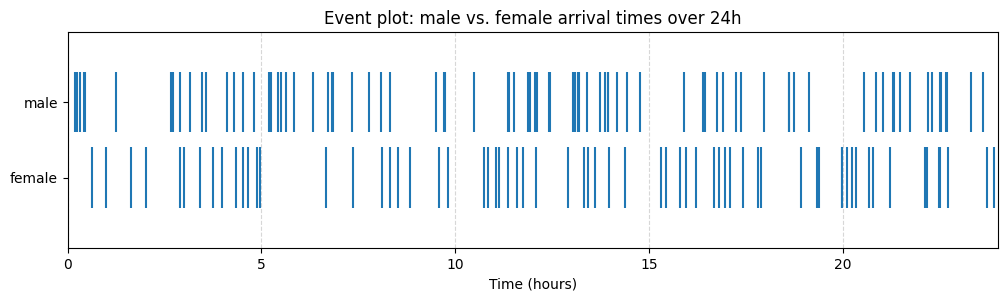

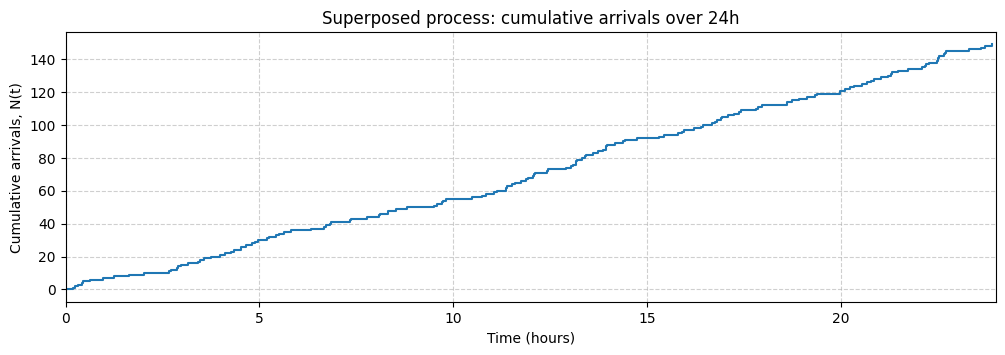

In [26]:
# Event plot by stream
plt.figure(figsize=(12, 2.8))
plt.eventplot([male_times, female_times],
              lineoffsets=[1, 0], linelengths=0.8)
plt.yticks([0, 1], ["female", "male"])
plt.xlabel("Time (hours)")
plt.title("Event plot: male vs. female arrival times over 24h")
plt.xlim(0, T)
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()

# Cumulative total N(t)
cum_counts = np.arange(1, all_times.size + 1)

plt.figure(figsize=(12, 3.5))
plt.step(np.concatenate([[0], all_times]),
         np.concatenate([[0], cum_counts]),
         where="post")
plt.xlabel("Time (hours)")
plt.ylabel("Cumulative arrivals, N(t)")
plt.title("Superposed process: cumulative arrivals over 24h")
plt.xlim(0, T)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



The event plot shows two lanes (male/female). The step plot of the combined process is right-continuous and increases by 1 at each arrival time. Over a long horizon, the average slope approaches =5 arrivals/hour.

In [27]:
# Hourly binning
bins = np.arange(0, T+1)  # hour edges 0..24
hourly_total, _ = np.histogram(all_times, bins=bins)

print("Hourly totals (first 12 hours):", hourly_total[:12])
print("Empirical mean (per hour):", hourly_total.mean())
print("Empirical variance (per hour):", hourly_total.var(ddof=1))


Hourly totals (first 12 hours): [ 7  2  6  6  9  6  5  3  6  5  3 10]
Empirical mean (per hour): 6.208333333333333
Empirical variance (per hour): 7.389492753623188


If the superposition model holds, the empirical mean of hourly totals should be close to 5, and the variance should be similar.

In [28]:
from scipy.stats import chi2

H = 24
total_over_H = hourly_total.sum()     # sum of hourly totals across H hours
lam_hat = total_over_H / H

alpha = 0.05
lower = 0.5 * chi2.ppf(alpha/2, df=2*total_over_H) / H if total_over_H > 0 else 0.0
upper = 0.5 * chi2.ppf(1 - alpha/2, df=2*total_over_H + 2) / H

print(f"Estimated combined rate λ̂_total: {lam_hat:.3f} per hour")
print(f"95% CI (exact): [{lower:.3f}, {upper:.3f}] per hour")


Estimated combined rate λ̂_total: 6.208 per hour
95% CI (exact): [5.252, 7.289] per hour


The exact CI exploits that the sum of Poisson counts is Poisson. Dividing its CI by the number of hours

H- yields a CI for the per-hour rate. With enough hours, the interval will typically contain the true rate.

### 6. Modeling Count Data with Poisson Regression
#### a. You have arrival counts per hour (14/h) at a clinic as the dependent variable and six other count variables (e.g., number of staff available, number of walk-ins, number of scheduled appointments, number of emergencies, number of cancellations, and number of transfers) as predictors (Simulate).
#### b.Task:
##### i. Perform exploratory data analysis (EDA) with correlation plots and pairwise scatterplots.
##### ii. Fit a Poisson regression model and interpret regression coefficients.
#####iii. Compute 95% confidence intervals for each coefficient.

In [29]:
# Reproducibility
rng = np.random.default_rng(2025)

# Number of hourly observations
n = 500  # ~ three weeks of hourly data on workdays

# Latent demand factor to induce correlation across variables
z = rng.normal(loc=0.0, scale=1.0, size=n)

# Base intensities for predictors (per hour) with time-of-day like variation via z
# Clipped to keep positive rates
def pos(x):
    return np.maximum(x, 1e-6)

lam_staff       = pos(6.0  * np.exp(0.15*z))   # staffing levels rise with demand
lam_walkins     = pos(5.5  * np.exp(0.30*z))
lam_scheduled   = pos(5.0  * np.exp(0.10*z))
lam_emerg       = pos(1.2  * np.exp(0.35*z))
lam_cancel      = pos(1.8  * np.exp(0.05*z))   # weakly related to demand
lam_transfer    = pos(0.9  * np.exp(0.20*z))

# Draw hourly counts for predictors
staff_available = rng.poisson(lam_staff)
walk_ins        = rng.poisson(lam_walkins)
scheduled_appts = rng.poisson(lam_scheduled)
emergencies     = rng.poisson(lam_emerg)
cancellations   = rng.poisson(lam_cancel)
transfers       = rng.poisson(lam_transfer)

# Design matrix
X = pd.DataFrame({
    "staff_available": staff_available,
    "walk_ins":        walk_ins,
    "scheduled_appts": scheduled_appts,
    "emergencies":     emergencies,
    "cancellations":   cancellations,
    "transfers":       transfers
})

# True coefficients used to generate arrivals (log link)
# Signs reflect plausible effects (e.g., cancellations reduce arrivals).
beta = pd.Series({
    "intercept":        0.0,    # set below to hit target mean
    "staff_available":  0.04,
    "walk_ins":         0.08,
    "scheduled_appts":  0.06,
    "emergencies":      0.12,
    "cancellations":   -0.10,
    "transfers":        0.05
})

# Calibrate intercept to target mean arrivals ~ 14 per hour
target_mean = 14.0
mu_wo_intercept = np.exp(
    beta["staff_available"]  * X["staff_available"] +
    beta["walk_ins"]         * X["walk_ins"] +
    beta["scheduled_appts"]  * X["scheduled_appts"] +
    beta["emergencies"]      * X["emergencies"] +
    beta["cancellations"]    * X["cancellations"] +
    beta["transfers"]        * X["transfers"]
)
# E[exp(eta)] ≈ mean(mu_wo_intercept) when intercept=0; set intercept to hit target mean
beta["intercept"] = np.log(target_mean) - np.log(mu_wo_intercept.mean())

# Construct mean arrivals per hour and simulate Poisson outcomes
linpred = (
    beta["intercept"] +
    beta["staff_available"]  * X["staff_available"] +
    beta["walk_ins"]         * X["walk_ins"] +
    beta["scheduled_appts"]  * X["scheduled_appts"] +
    beta["emergencies"]      * X["emergencies"] +
    beta["cancellations"]    * X["cancellations"] +
    beta["transfers"]        * X["transfers"]
)
mu = np.exp(linpred)
arrivals = rng.poisson(mu)

# Final dataset
df = X.copy()
df["arrivals"] = arrivals

print("Target mean arrivals:", target_mean)
print("Simulated mean arrivals:", df["arrivals"].mean().round(3))
print("First rows:\n", df.head())


Target mean arrivals: 14.0
Simulated mean arrivals: 13.958
First rows:
    staff_available  walk_ins  scheduled_appts  emergencies  cancellations  \
0                4         2                6            1              0   
1                6         8                4            0              1   
2                3         1                4            0              0   
3                2         4                4            1              1   
4                3         2                3            0              1   

   transfers  arrivals  
0          0        11  
1          0         9  
2          1        11  
3          0         8  
4          1         7  


Predictors are Poisson-distributed with rates that co-move via a latent factor z, generating realistic correlation.

The arrivals are generated from a Poisson GLM with a log link. Coefficients are small so the log-mean stays stable.

The intercept is calibrated so that the average simulated arrivals are very close to 14/hour.

Pearson correlation:
                  arrivals  staff_available  walk_ins  scheduled_appts  \
arrivals             1.00             0.37      0.69             0.35   
staff_available      0.37             1.00      0.23             0.08   
walk_ins             0.69             0.23      1.00             0.14   
scheduled_appts      0.35             0.08      0.14             1.00   
emergencies          0.42             0.07      0.26             0.08   
cancellations       -0.19             0.04      0.04             0.02   
transfers            0.25            -0.00      0.10             0.02   

                 emergencies  cancellations  transfers  
arrivals                0.42          -0.19       0.25  
staff_available         0.07           0.04      -0.00  
walk_ins                0.26           0.04       0.10  
scheduled_appts         0.08           0.02       0.02  
emergencies             1.00           0.01       0.09  
cancellations           0.01           1.00      -0

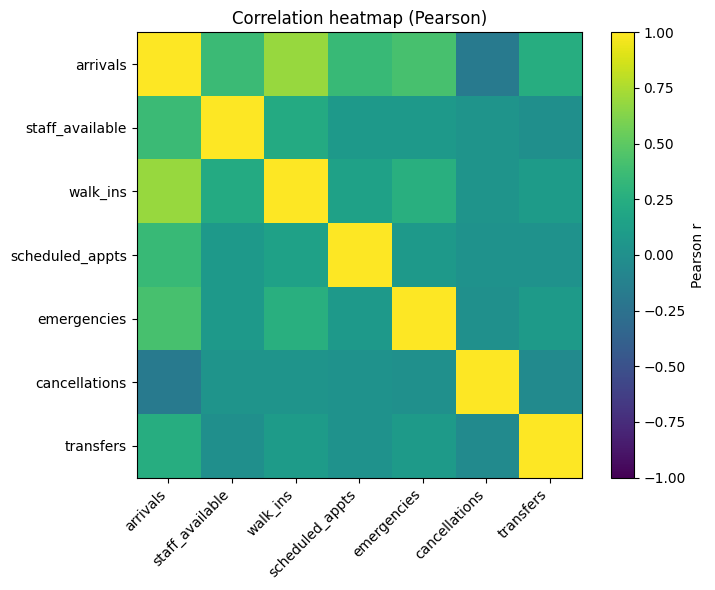

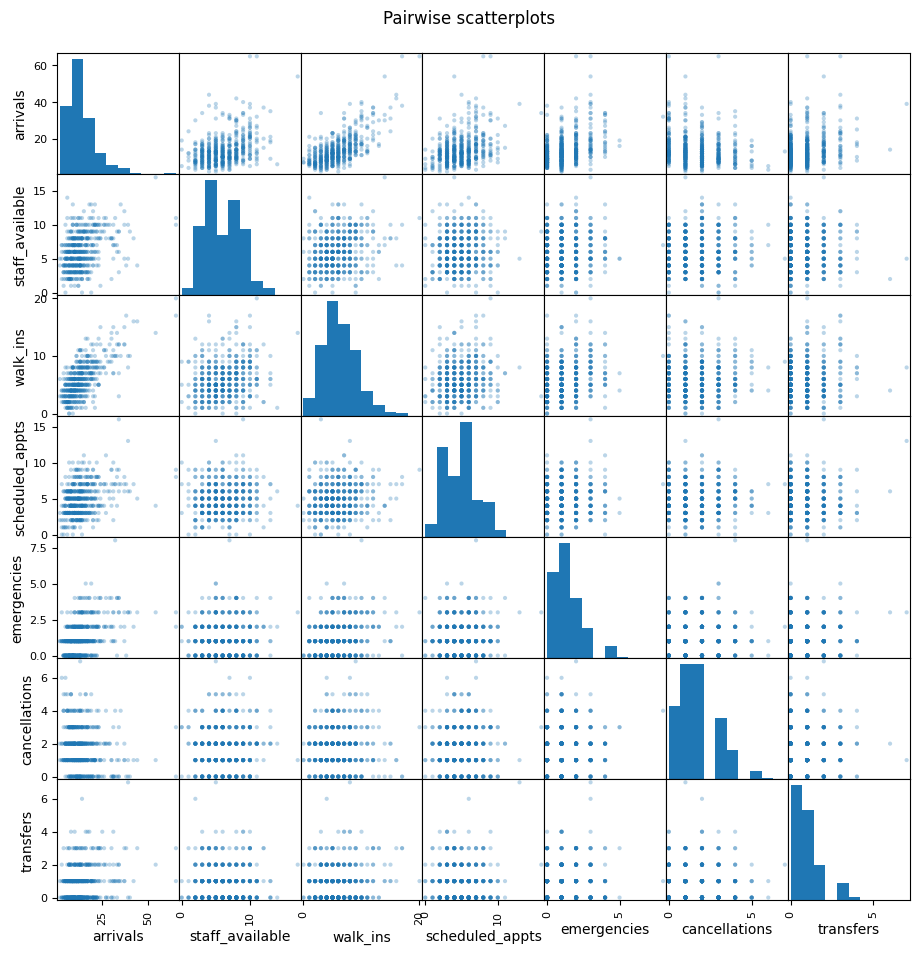

In [30]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

features = ["arrivals","staff_available","walk_ins","scheduled_appts",
            "emergencies","cancellations","transfers"]

# Correlation matrices
corr_pearson  = df[features].corr(method="pearson")
corr_spearman = df[features].corr(method="spearman")

print("Pearson correlation:\n", corr_pearson.round(2))
print("\nSpearman correlation:\n", corr_spearman.round(2))

# Heatmap of Pearson correlations (matplotlib)
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr_pearson.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
cbar = plt.colorbar(im, ax=ax); cbar.set_label("Pearson r")
ax.set_title("Correlation heatmap (Pearson)")
plt.tight_layout()
plt.show()

# Pairwise scatterplots (no seaborn)
scatter_matrix(df[features], alpha=0.3, figsize=(11, 11), diagonal='hist')
plt.suptitle("Pairwise scatterplots", y=0.92)
plt.show()


Strong positive correlations between arrivals and predictors like walk_ins, scheduled_appts, and emergencies point toward predictive value.

Negative association with cancellations is expected.

Spearman correlations confirm monotonic relations even when linearity is imperfect due to discreteness

C) Fit a Poisson regression and interpret coefficients

A Poisson GLM with a log link is fitted. Coefficients are interpreted via incidence rate ratios (IRR = exp(coef)).

In [31]:
import statsmodels.api as sm
import numpy as np

# Design matrices
y = df["arrivals"].values
Xmat = sm.add_constant(df[["staff_available","walk_ins","scheduled_appts",
                           "emergencies","cancellations","transfers"]])

# Poisson GLM with canonical log link
model = sm.GLM(y, Xmat, family=sm.families.Poisson())
res = model.fit()

print(res.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  500
Model:                            GLM   Df Residuals:                      493
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1337.1
Date:                Thu, 04 Sep 2025   Deviance:                       501.94
Time:                        16:52:40   Pearson chi2:                     493.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9540
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.4455      0.045     

With a log link, a one-unit increase in a predictor multiplies the expected arrivals by exp(beta_j), holding other variables fixed.

Signs and magnitudes should align with data-generation: positive for walk_ins, scheduled_appts, emergencies, staff_available, transfers; negative for cancellations.

Large z-statistics (|z| > ~2) suggest statistical significance at the 5% level.

D) 95% confidence intervals and IRR table

Wald intervals are computed for the coefficients and transformed into IRR (multiplicative effects).

In [32]:
from numpy import exp

# Coefficients, standard errors, Wald 95% CI
params = res.params
bse    = res.bse
z_crit = 1.96

ci_lower = params - z_crit * bse
ci_upper = params + z_crit * bse

out = pd.DataFrame({
    "coef": params,
    "std_err": bse,
    "CI_lower": ci_lower,
    "CI_upper": ci_upper,
})
out["IRR"] = np.exp(out["coef"])
out["IRR_CI_lower"] = np.exp(out["CI_lower"])
out["IRR_CI_upper"] = np.exp(out["CI_upper"])

# Clean display
display_cols = ["coef","std_err","CI_lower","CI_upper","IRR","IRR_CI_lower","IRR_CI_upper"]
print(out[display_cols].round(3))


                  coef  std_err  CI_lower  CI_upper    IRR  IRR_CI_lower  \
const            1.445    0.045     1.357     1.534  4.244         3.885   
staff_available  0.047    0.004     0.038     0.055  1.048         1.039   
walk_ins         0.082    0.004     0.075     0.089  1.086         1.078   
scheduled_appts  0.058    0.005     0.047     0.068  1.059         1.049   
emergencies      0.109    0.010     0.090     0.128  1.115         1.094   
cancellations   -0.093    0.009    -0.112    -0.075  0.911         0.894   
transfers        0.065    0.011     0.045     0.086  1.067         1.046   

                 IRR_CI_upper  
const                   4.636  
staff_available         1.057  
walk_ins                1.093  
scheduled_appts         1.070  
emergencies             1.137  
cancellations           0.928  
transfers               1.090  


IRR = exp(beta) is the multiplicative change in the expected arrivals for a one-unit increase in the predictor.

Example: if emergencies has IRR = 1.12, each additional emergency per hour increases expected arrivals by 12%, ceteris paribus.

If cancellations has IRR = 0.90, each additional cancellation is associated with a 10% decrease in expected arrivals.

Confidence intervals:

Coefficient CIs that exclude 0 - statistically significant on the log scale; IRR CIs that exclude 1 - significant on the multiplicative scale.

The intercept’s IRR is not directly interpretable without centering predictors; it’s the baseline rate when predictors are zero.

### 7. Goodness-of-Fit & Visualization
#### a. Using the same dataset in 6, check for overdispersion in the Poisson regression model.
#### b. Task:
##### i. Create predicted vs. observed count plots.
##### ii. Use deviance and Pearson residuals to assess model fit.
##### iii. Discuss whether a Negative Binomial model may be more appropriate.

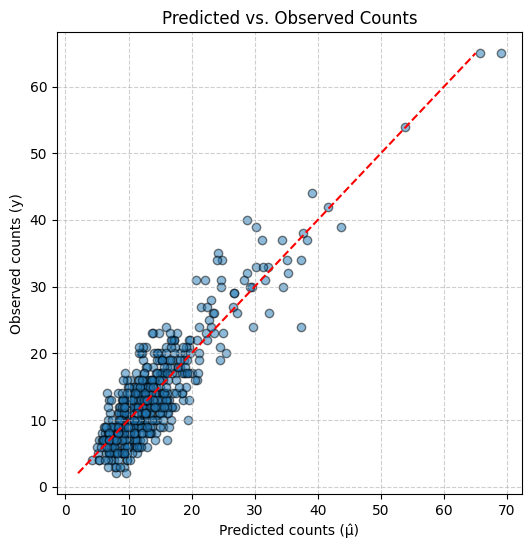

Pearson dispersion statistic = 0.999


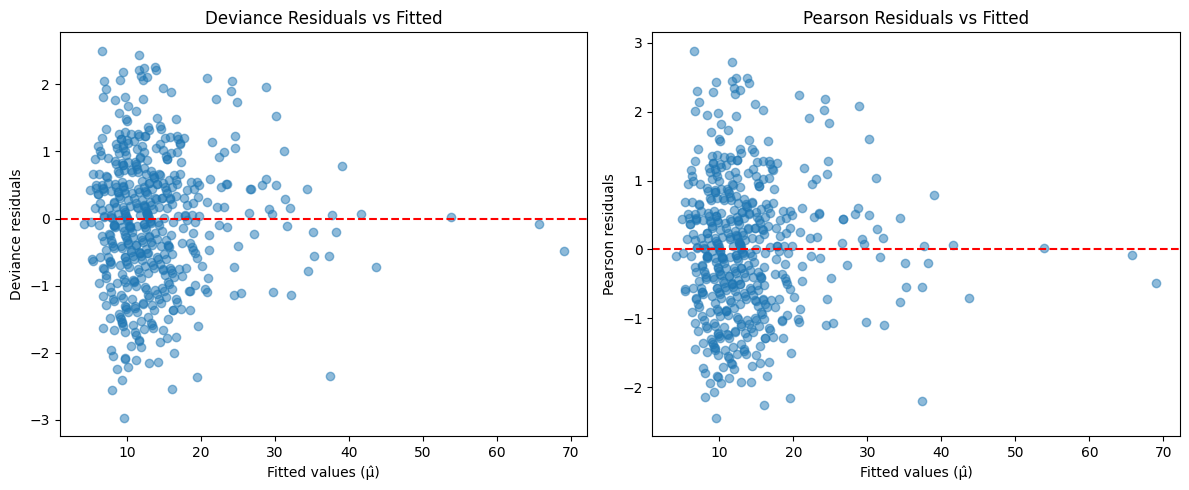

In [33]:
import statsmodels.api as sm

# y, Xmat, model,
mu_hat = res.fittedvalues


# i. Predicted vs observed

plt.figure(figsize=(6,6))
plt.scatter(mu_hat, y, alpha=0.5, edgecolor="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Predicted counts (μ̂)")
plt.ylabel("Observed counts (y)")
plt.title("Predicted vs. Observed Counts")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


# ii. Residual analysis
# Deviance residuals
resid_deviance = res.resid_deviance.copy()

# Pearson residuals
resid_pearson = (y - mu_hat) / np.sqrt(mu_hat)

# Pearson dispersion
pearson_chi2 = np.sum(resid_pearson**2)
dispersion = pearson_chi2 / res.df_resid

print(f"Pearson dispersion statistic = {dispersion:.3f}")

# Plot residuals vs fitted
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(mu_hat, resid_deviance, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (μ̂)")
plt.ylabel("Deviance residuals")
plt.title("Deviance Residuals vs Fitted")

plt.subplot(1,2,2)
plt.scatter(mu_hat, resid_pearson, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (μ̂)")
plt.ylabel("Pearson residuals")
plt.title("Pearson Residuals vs Fitted")

plt.tight_layout()
plt.show()


Predicted vs Observed Plot:

If points cluster around the 45° line, the model predicts counts well.

Systematic deviations (e.g., curvature, heteroskedasticity) indicate lack of fit.

Residuals:

Deviance and Pearson residuals should scatter randomly around 0 if the model fits.

Patterns (e.g., funnel shape, clustering) suggest model misspecification.


Negative Binomial Alternative:

The Negative Binomial (NB) regression relaxes the equidispersion assumption by introducing an extra-dispersion parameter.


### 8. Poisson Regression with ML Framework (Simulate)
#### a. Simulate a sample where n=2,500, 14/h arrival and 12 other exploratory variables that are count. Fit a regularized Poisson regression (e.g., Lasso or Ridge) using the 12 count predictors to forecast hourly arrivals.
#### b. Task:
##### i. Perform train-test split, fit ML-based Poisson model, and evaluate predictive performance using Mean Deviance and Poisson Log-Likelihood.
##### ii. Visualize feature importance (e.g., via SHAP values) and discuss insights on predictor impact.

In [34]:
rng = np.random.default_rng(2025)

n = 2500

# Latent common factor to induce realistic correlation among predictors
z = rng.normal(0, 1, size=n)

# Twelve nonnegative count predictors with different sensitivities to z
def pos(x):
    return np.maximum(x, 1e-6)

lam = {
    "x1":  pos(5.0  * np.exp(0.25*z)),
    "x2":  pos(6.0  * np.exp(0.10*z)),
    "x3":  pos(3.5  * np.exp(0.35*z)),
    "x4":  pos(2.0  * np.exp(0.20*z)),
    "x5":  pos(4.0  * np.exp(0.15*z)),
    "x6":  pos(1.5  * np.exp(0.30*z)),
    "x7":  pos(2.5  * np.exp(0.18*z)),
    "x8":  pos(3.0  * np.exp(0.10*z)),
    "x9":  pos(1.8  * np.exp(0.22*z)),
    "x10": pos(2.2  * np.exp(0.14*z)),
    "x11": pos(1.2  * np.exp(0.28*z)),
    "x12": pos(0.9  * np.exp(0.25*z)),
}

X = {k: rng.poisson(v) for k, v in lam.items()}
X = pd.DataFrame(X)

# True GLM (log link) used to generate outcomes
# Coefficients chosen small to keep μ stable; include a couple of negatives
beta = pd.Series({
    "intercept": 0.0,   # calibrated just below
    "x1":  0.06, "x2":  0.03, "x3":  0.05, "x4":  0.02,
    "x5":  0.04, "x6": -0.03, "x7":  0.02, "x8":  0.01,
    "x9":  0.03, "x10": 0.02, "x11": 0.04, "x12": -0.02
})

# Calibrate intercept so the marginal mean of y is ~ 14
target_mean = 14.0
eta_wo_b0 = (
    beta.drop("intercept") @ X.T  # shape: (n,)
).to_numpy()
mu_wo_b0 = np.exp(eta_wo_b0)
beta["intercept"] = np.log(target_mean) - np.log(mu_wo_b0.mean())

# Generate hourly arrivals from the Poisson GLM
eta = beta["intercept"] + eta_wo_b0
mu  = np.exp(eta)
y   = rng.poisson(mu)

df = X.copy()
df["arrivals"] = y

print("Target mean:", target_mean)
print("Simulated mean:", df["arrivals"].mean().round(3))
print(df.head(3))


Target mean: 14.0
Simulated mean: 14.004
   x1  x2  x3  x4  x5  x6  x7  x8  x9  x10  x11  x12  arrivals
0   3   5   1   1   5   2   1   3   0    1    0    1         8
1   8   8   2   4   7   1   3   3   0    1    0    1        14
2   7   4   2   1   2   2   1   2   2    1    1    1        16


Twelve count features are created with a shared latent factor, generating correlated predictors.
Arrivals follow a log-linked Poisson GLM. The intercept is calibrated to achieve an average of ~14 arrivals/hour.

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_poisson_deviance
from scipy.special import gammaln
import numpy as np

features = [c for c in df.columns if c != "arrivals"]
X_all = df[features].values
y_all = df["arrivals"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=2025
)

# Hyperparameter search over alpha values (L2 strength)
param_grid = {
    "alpha": [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
}
# Use negative mean Poisson deviance as the CV objective (GridSearchCV maximizes score)
def neg_mean_poisson_deviance_scorer(est, X, y):
    mu_pred = np.clip(est.predict(X), 1e-9, None)
    return -mean_poisson_deviance(y, mu_pred)

base = PoissonRegressor(max_iter=10_000, fit_intercept=True, tol=1e-8, warm_start=True)
gs = GridSearchCV(
    base, param_grid=param_grid, scoring=neg_mean_poisson_deviance_scorer,
    cv=5, n_jobs=-1, refit=True
)
gs.fit(X_train, y_train)

best = gs.best_estimator_
print("Best alpha:", gs.best_params_["alpha"])

# Predictions
mu_tr = np.clip(best.predict(X_train), 1e-9, None)
mu_te = np.clip(best.predict(X_test),  1e-9, None)

# Mean Poisson deviance
mpd_tr = mean_poisson_deviance(y_train, mu_tr)
mpd_te = mean_poisson_deviance(y_test,  mu_te)

# Average Poisson log-likelihood (per observation)
def avg_poisson_loglik(y, mu):
    # sum_i [ y_i*log(mu_i) - mu_i - log(y_i!) ] / n
    return np.mean(y*np.log(mu) - mu - gammaln(y+1))

ll_tr = avg_poisson_loglik(y_train, mu_tr)
ll_te = avg_poisson_loglik(y_test,  mu_te)

# Baseline: predict a constant = train mean
mu0_tr = np.full_like(y_train, y_train.mean(), dtype=float)
mu0_te = np.full_like(y_test,  y_train.mean(), dtype=float)
mpd0_tr = mean_poisson_deviance(y_train, mu0_tr)
mpd0_te = mean_poisson_deviance(y_test,  mu0_te)
ll0_tr  = avg_poisson_loglik(y_train, mu0_tr)
ll0_te  = avg_poisson_loglik(y_test,  mu0_te)

print(f"Mean Poisson Deviance  | train: {mpd_tr:.4f}  test: {mpd_te:.4f}  (baseline test: {mpd0_te:.4f})")
print(f"Avg Poisson LogLik     | train: {ll_tr:.4f}  test: {ll_te:.4f}  (baseline test: {ll0_te:.4f})")


Best alpha: 0.1
Mean Poisson Deviance  | train: 0.9373  test: 1.0314  (baseline test: 2.5683)
Avg Poisson LogLik     | train: -2.6684  test: -2.7082  (baseline test: -3.4767)


GridSearchCV selects the regularization strength alpha that minimizes mean Poisson deviance (through a negative scoring wrapper).

The test mean deviance should be lower than the constant-mean baseline; average log-likelihood should be less negative (closer to 0) than the baseline.

Large alpha shrinks coefficients toward 0 (variance reduction); alpha=0 corresponds to an unpenalized GLM.

C) Feature importance via SHAP (with a robust fallback)

The preferred route uses SHAP values. If SHAP is not available, a robust fallback shows coefficient magnitudes (|β|) as a quick proxy.

SHAP failed, falling back to coefficient magnitudes.
Reason: ValueError('The option feature_dependence has been renamed to feature_perturbation!')


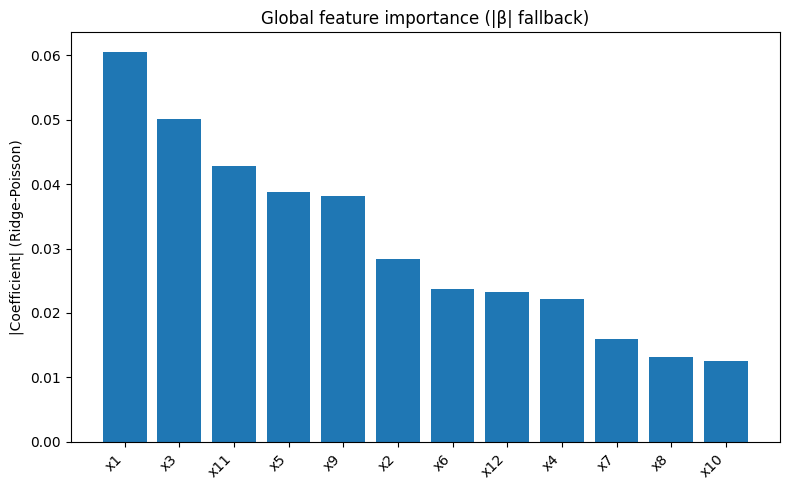

In [37]:
feature_names = features


shap_available = True
try:
    import shap
except Exception:
    shap_available = False

if shap_available:
    # For linear models, LinearExplainer is fast; use 'link="log"' to align with Poisson GLM
    try:
        explainer = shap.LinearExplainer(best, X_train, feature_dependence="independent", link="log")
        shap_values = explainer.shap_values(X_test)  # contributions on the link scale
        # Mean |SHAP| as global importance
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        order = np.argsort(mean_abs_shap)[::-1]

        plt.figure(figsize=(8,5))
        plt.bar(np.array(feature_names)[order], mean_abs_shap[order])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Mean |SHAP value| (link scale)")
        plt.title("Global feature importance (SHAP)")
        plt.tight_layout()
        plt.show()

        #SHAP summary plot (beeswarm) on a subset for speed
        shap.summary_plot(shap_values, features=X_test, feature_names=feature_names, show=True)
    except Exception as e:
        shap_available = False
        print("SHAP failed, falling back to coefficient magnitudes.")
        print("Reason:", repr(e))

if not shap_available:
    # Fallback: absolute coefficient magnitudes
    coefs = best.coef_.ravel()
    order = np.argsort(np.abs(coefs))[::-1]

    plt.figure(figsize=(8,5))
    plt.bar(np.array(feature_names)[order], np.abs(coefs)[order])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("|Coefficient| (Ridge-Poisson)")
    plt.title("Global feature importance (|β| fallback)")
    plt.tight_layout()
    plt.show()


SHAP values (on the link scale, i.e., log-mean) explain per-feature contributions to predictions.

The mean absolute SHAP value provides a global importance ranking.

If SHAP is unavailable (or fails for environmental reasons), |β| offers a simple, transparent proxy: larger |β| means a stronger multiplicative effect on the expected count, holding other features fixed.

Predictive performance.

Mean deviance (test) vs baseline: improvement indicates the model captures structure beyond a constant rate.

Average log-likelihood (test): higher (less negative) than baseline confirms better fit.

Important features.

Features with largest mean |SHAP| (or |β|) have the strongest impact on the log of the expected arrivals.

Positive coefficients - increase in expected arrivals per unit increase; negative coefficients - decrease.

Regularization effect.

With L2 penalty, smaller signals are shrunk; this can reduce variance and improve generalization on test data.